In [3]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv(r"pd_speech_features.csv")

In [5]:
# displaying the first five rows of the dataset
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [6]:
# displaying last 5 records of the dataset
df.tail()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
751,250,0,0.80903,0.56355,0.28385,417,416,0.004627,0.000052,0.00064,...,3.0706,3.0190,3.1212,2.4921,3.5844,3.5400,3.3805,3.2003,6.8671,0
752,250,0,0.16084,0.56499,0.59194,415,413,0.004550,0.000220,0.00143,...,1.9704,1.7451,1.8277,2.4976,5.2981,4.2616,6.3042,10.9058,28.4170,0
753,251,0,0.88389,0.72335,0.46815,381,380,0.005069,0.000103,0.00076,...,51.5607,44.4641,26.1586,6.3076,2.8601,2.5361,3.5377,3.3545,5.0424,0
754,251,0,0.83782,0.74890,0.49823,340,339,0.005679,0.000055,0.00092,...,19.1607,12.8312,8.9434,2.2044,1.9496,1.9664,2.6801,2.8332,3.7131,0
755,251,0,0.81304,0.76471,0.46374,340,339,0.005676,0.000037,0.00078,...,62.9927,21.8152,9.2457,4.8555,3.0551,3.0415,4.0116,2.6217,3.1527,0


In [7]:
# Let's check the shape of the dataset
df.shape

(756, 755)

In [8]:
# getting the columns of the dataset
df.columns

Index(['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses',
       'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter',
       ...
       'tqwt_kurtosisValue_dec_28', 'tqwt_kurtosisValue_dec_29',
       'tqwt_kurtosisValue_dec_30', 'tqwt_kurtosisValue_dec_31',
       'tqwt_kurtosisValue_dec_32', 'tqwt_kurtosisValue_dec_33',
       'tqwt_kurtosisValue_dec_34', 'tqwt_kurtosisValue_dec_35',
       'tqwt_kurtosisValue_dec_36', 'class'],
      dtype='str', length=755)

In [9]:
# checking of null values 
df.isnull().sum()

id                           0
gender                       0
PPE                          0
DFA                          0
RPDE                         0
                            ..
tqwt_kurtosisValue_dec_33    0
tqwt_kurtosisValue_dec_34    0
tqwt_kurtosisValue_dec_35    0
tqwt_kurtosisValue_dec_36    0
class                        0
Length: 755, dtype: int64

In [10]:
#total missing data
train_total = df.isnull().sum()
train_percent= ((df.isnull().sum()/df.shape[0])*100)

data_missing= pd.DataFrame({'train total':train_total, 'train percent': train_percent})
data_missing.sort_values(by='train total', ascending=False).head()

,train total,train percent
id,0,0.0
tqwt_medianValue_dec_6,0,0.0
tqwt_TKEO_std_dec_33,0,0.0
tqwt_TKEO_std_dec_34,0,0.0
tqwt_TKEO_std_dec_35,0,0.0


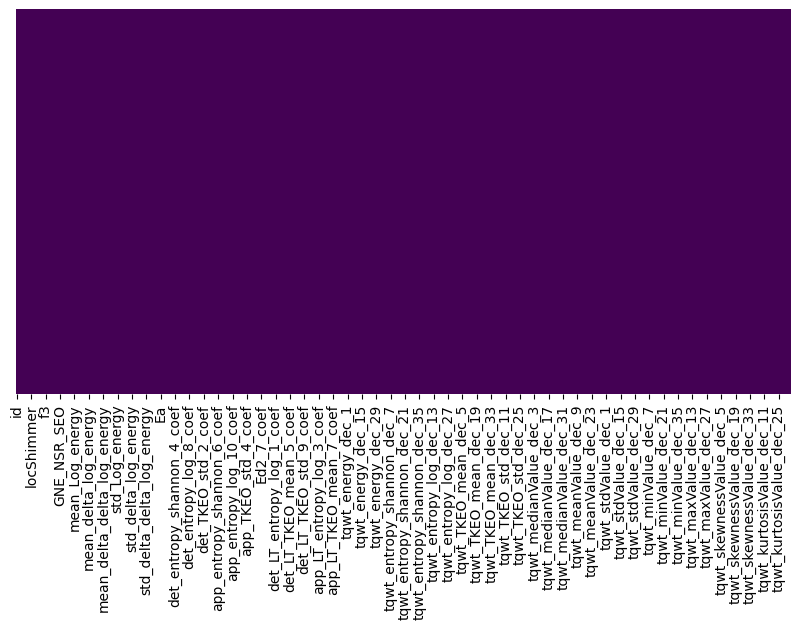

In [11]:
# plot the line plot to show the missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

In [12]:
# checking the datatypes of the columns
df.dtypes

id                             int64
gender                         int64
PPE                          float64
DFA                          float64
RPDE                         float64
                              ...   
tqwt_kurtosisValue_dec_33    float64
tqwt_kurtosisValue_dec_34    float64
tqwt_kurtosisValue_dec_35    float64
tqwt_kurtosisValue_dec_36    float64
class                          int64
Length: 755, dtype: object

In [13]:
# checking the information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


In [14]:
# statistical summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,756.0,125.500000,72.793721,0.000000,62.750000,125.500000,188.250000,251.00000
gender,756.0,0.515873,0.500079,0.000000,0.000000,1.000000,1.000000,1.00000
PPE,756.0,0.746284,0.169294,0.041551,0.762833,0.809655,0.834315,0.90766
DFA,756.0,0.700414,0.069718,0.543500,0.647053,0.700525,0.754985,0.85264
RPDE,756.0,0.489058,0.137442,0.154300,0.386537,0.484355,0.586515,0.87123
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,756.0,12.375335,16.341665,1.628700,3.114375,4.741450,12.201325,73.53220
tqwt_kurtosisValue_dec_34,756.0,14.799230,15.722502,1.861700,3.665925,6.725700,21.922050,62.00730
tqwt_kurtosisValue_dec_35,756.0,14.751559,14.432979,1.955900,3.741275,7.334250,22.495175,57.54430
tqwt_kurtosisValue_dec_36,756.0,31.481110,34.230991,2.364000,3.948750,10.637250,61.125325,156.42370


In [15]:
# checking the unique values of the dataset
df.nunique()

id                           252
gender                         2
PPE                          740
DFA                          745
RPDE                         748
                            ... 
tqwt_kurtosisValue_dec_33    752
tqwt_kurtosisValue_dec_34    753
tqwt_kurtosisValue_dec_35    753
tqwt_kurtosisValue_dec_36    754
class                          2
Length: 755, dtype: int64

In [16]:
df.columns

Index(['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses',
       'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter',
       ...
       'tqwt_kurtosisValue_dec_28', 'tqwt_kurtosisValue_dec_29',
       'tqwt_kurtosisValue_dec_30', 'tqwt_kurtosisValue_dec_31',
       'tqwt_kurtosisValue_dec_32', 'tqwt_kurtosisValue_dec_33',
       'tqwt_kurtosisValue_dec_34', 'tqwt_kurtosisValue_dec_35',
       'tqwt_kurtosisValue_dec_36', 'class'],
      dtype='str', length=755)

In [17]:
l = []
for i in df.columns:
    if df[i].dtype == 'object':
        l.append(i)
print(l)

[]


In [18]:
x = df.drop('class', axis=1)
y = df['class']

In [19]:
df['class'].value_counts().to_dict()

{1: 564, 0: 192}

In [21]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=1)
x, y = sm.fit_resample(x, y)

In [22]:
## Spliiting the data into trainingh and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((789, 754), (339, 754), (789,), (339,))

In [23]:
from sklearn.feature_selection import mutual_info_classif
# determine the mutual information
mutual_info = mutual_info_classif(x_train, y_train)
mutual_info

array([0.13198294, 0.03075734, 0.01147541, 0.05466815, 0.04877672,
       0.10212922, 0.09179987, 0.10592657, 0.02472501, 0.07354504,
       0.10820104, 0.12913633, 0.09385131, 0.08357199, 0.03783191,
       0.0527503 , 0.02154989, 0.04582742, 0.09017095, 0.01942394,
       0.05069609, 0.05529711, 0.02231718, 0.10168375, 0.13559947,
       0.12639069, 0.08731903, 0.03890578, 0.04270733, 0.00997203,
       0.0354107 , 0.02181699, 0.00320552, 0.02401636, 0.04595081,
       0.0231596 , 0.        , 0.04995927, 0.02807624, 0.        ,
       0.03481392, 0.00900722, 0.01882533, 0.05349507, 0.02011173,
       0.06001927, 0.00793613, 0.02863017, 0.01142036, 0.03205892,
       0.02190111, 0.02892099, 0.04398452, 0.03149431, 0.061834  ,
       0.02311134, 0.06201878, 0.047608  , 0.08308454, 0.08957119,
       0.06075699, 0.05966578, 0.051793  , 0.04588818, 0.00039844,
       0.02510144, 0.        , 0.02566082, 0.02808193, 0.0190385 ,
       0.06962024, 0.06492498, 0.01801372, 0.02907191, 0.00722

In [24]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = x_train.columns
mutual_info.sort_values(ascending=False)

app_LT_entropy_shannon_6_coef    0.211664
app_LT_entropy_log_6_coef        0.210433
app_entropy_shannon_9_coef       0.205454
app_entropy_shannon_8_coef       0.204829
app_entropy_log_6_coef           0.202663
                                   ...   
det_TKEO_std_5_coef              0.000000
tqwt_meanValue_dec_11            0.000000
mean_MFCC_9th_coef               0.000000
tqwt_entropy_log_dec_25          0.000000
tqwt_minValue_dec_32             0.000000
Length: 754, dtype: float64

<Axes: >

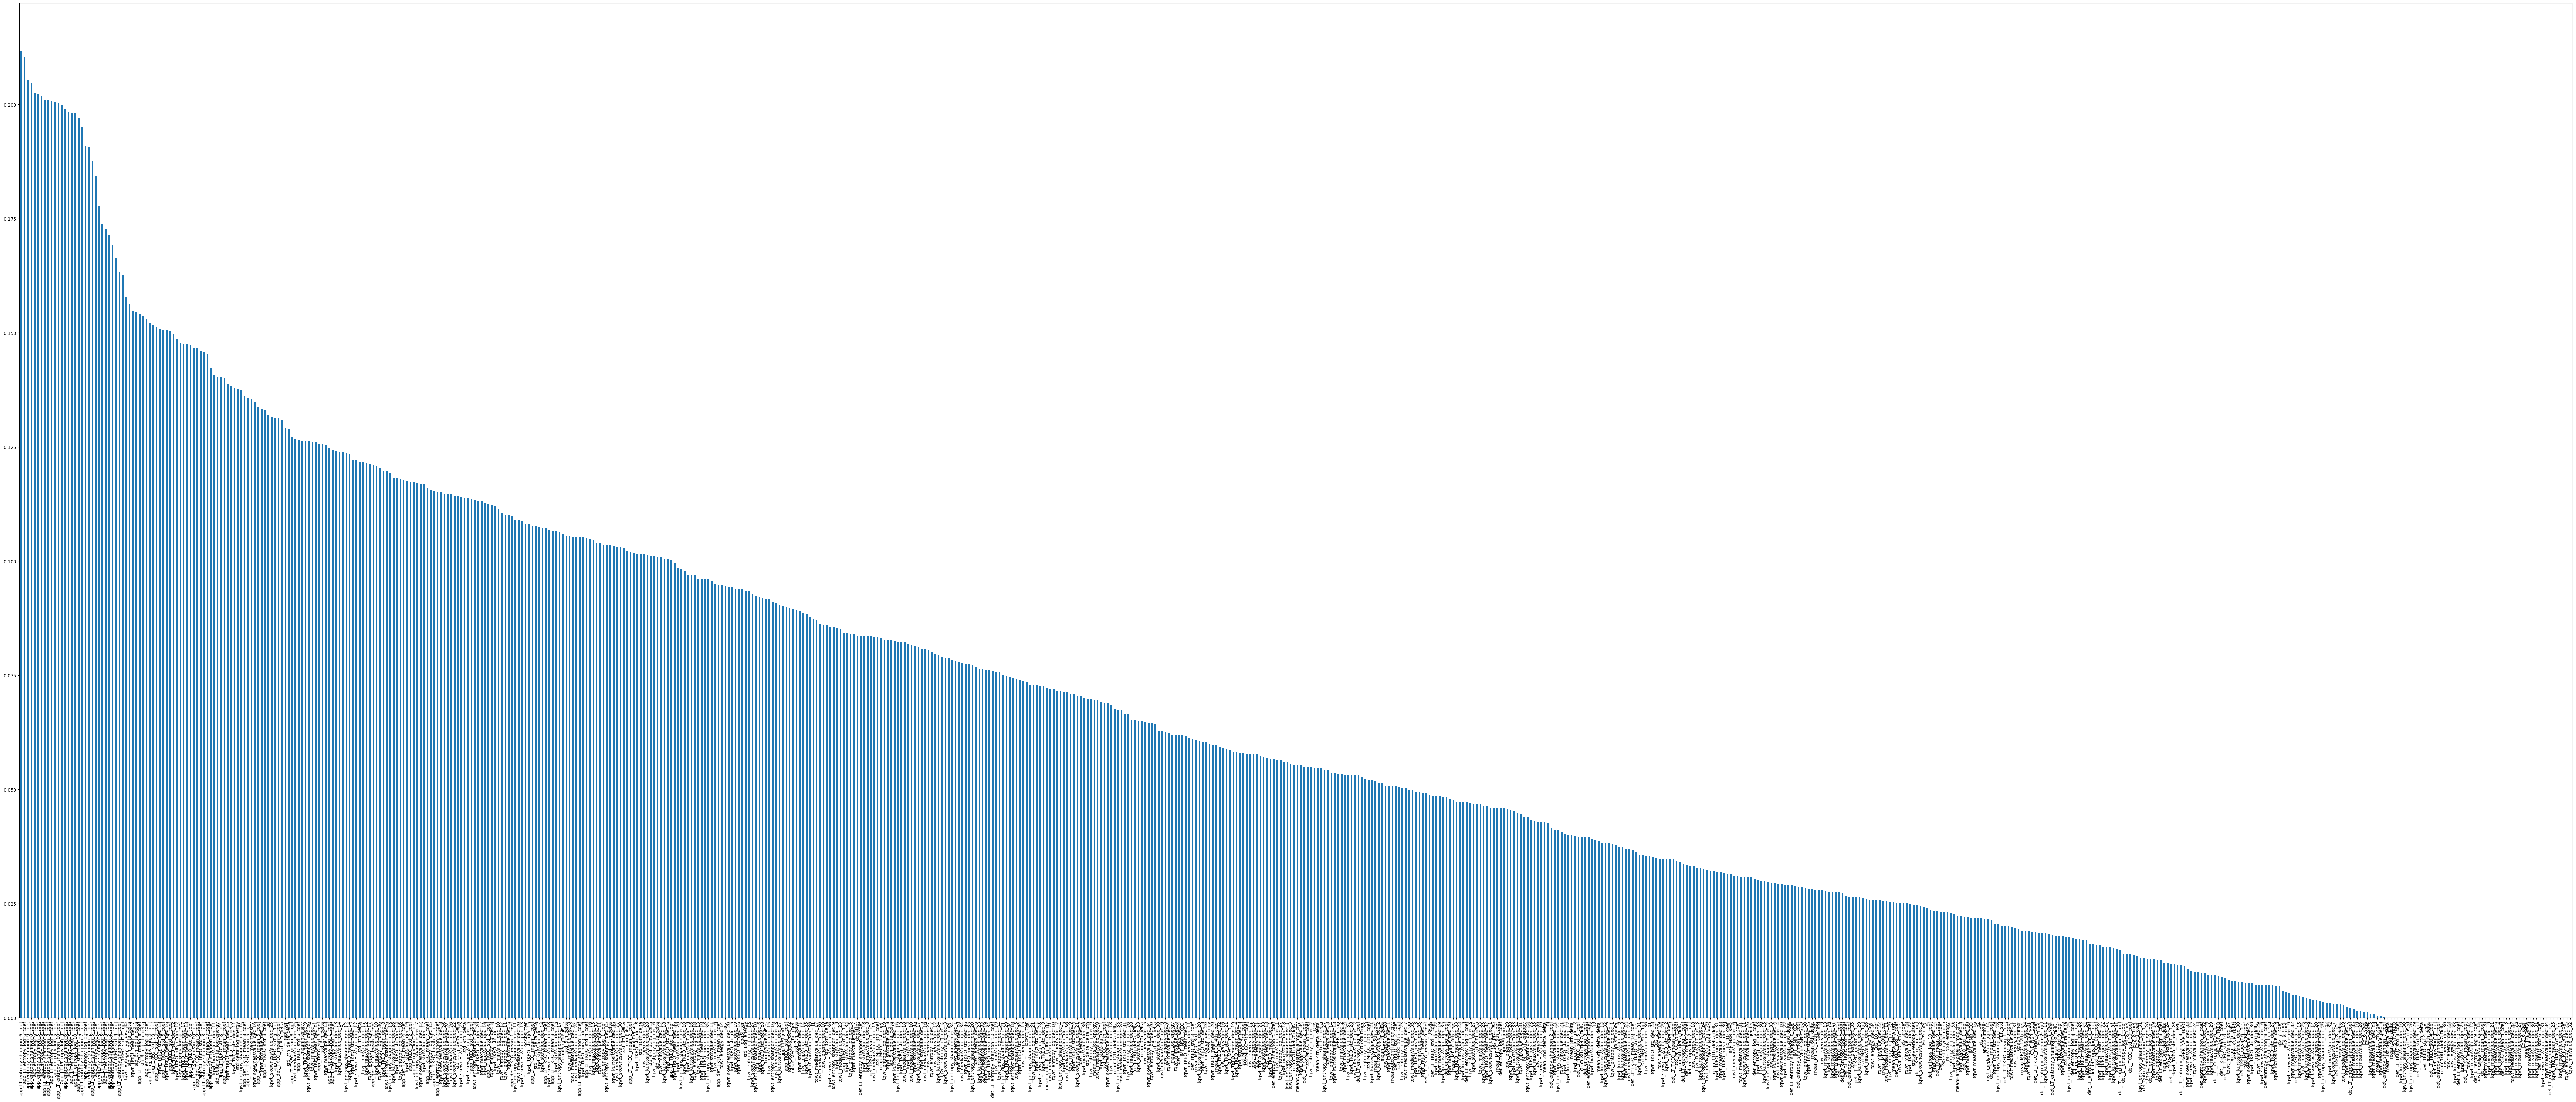

In [25]:
#let's plot the ordered mutual_info values per feature
mutual_info.sort_values(ascending=False).plot.bar(figsize=(100, 40))

In [26]:
from sklearn.feature_selection import SelectKBest

select_40_columns = SelectKBest(mutual_info_classif, k=40)
select_40_columns.fit(x_train, y_train)
x_train.columns[select_40_columns.get_support()]

Index(['std_6th_delta_delta', 'std_8th_delta_delta', 'std_9th_delta_delta',
       'app_entropy_shannon_2_coef', 'app_entropy_shannon_3_coef',
       'app_entropy_shannon_4_coef', 'app_entropy_shannon_5_coef',
       'app_entropy_shannon_6_coef', 'app_entropy_shannon_7_coef',
       'app_entropy_shannon_8_coef', 'app_entropy_shannon_9_coef',
       'app_entropy_shannon_10_coef', 'app_entropy_log_3_coef',
       'app_entropy_log_5_coef', 'app_entropy_log_6_coef',
       'app_entropy_log_7_coef', 'app_entropy_log_8_coef',
       'app_entropy_log_9_coef', 'app_entropy_log_10_coef',
       'app_TKEO_std_9_coef', 'app_TKEO_std_10_coef',
       'app_LT_entropy_shannon_4_coef', 'app_LT_entropy_shannon_5_coef',
       'app_LT_entropy_shannon_6_coef', 'app_LT_entropy_shannon_7_coef',
       'app_LT_entropy_shannon_8_coef', 'app_LT_entropy_shannon_9_coef',
       'app_LT_entropy_shannon_10_coef', 'app_LT_entropy_log_3_coef',
       'app_LT_entropy_log_4_coef', 'app_LT_entropy_log_5_coef',
      

In [27]:
x_train = x_train [['std_6th_delta_delta', 'std_8th_delta_delta', 'std_9th_delta_delta',
       'app_entropy_shannon_2_coef', 'app_entropy_shannon_3_coef',
       'app_entropy_shannon_4_coef', 'app_entropy_shannon_5_coef',
       'app_entropy_shannon_6_coef', 'app_entropy_shannon_7_coef',
       'app_entropy_shannon_8_coef', 'app_entropy_shannon_9_coef',
       'app_entropy_shannon_10_coef', 'app_entropy_log_3_coef',
       'app_entropy_log_5_coef', 'app_entropy_log_6_coef',
       'app_entropy_log_7_coef', 'app_entropy_log_8_coef',
       'app_entropy_log_9_coef', 'app_entropy_log_10_coef',
       'app_TKEO_std_9_coef', 'app_TKEO_std_10_coef',
       'app_LT_entropy_shannon_4_coef', 'app_LT_entropy_shannon_5_coef',
       'app_LT_entropy_shannon_6_coef', 'app_LT_entropy_shannon_7_coef',
       'app_LT_entropy_shannon_8_coef', 'app_LT_entropy_shannon_9_coef',
       'app_LT_entropy_shannon_10_coef', 'app_LT_entropy_log_3_coef',
       'app_LT_entropy_log_4_coef', 'app_LT_entropy_log_5_coef',
       'app_LT_entropy_log_6_coef', 'app_LT_entropy_log_7_coef',
       'app_LT_entropy_log_8_coef', 'app_LT_entropy_log_9_coef',
       'app_LT_entropy_log_10_coef', 'app_LT_TKEO_mean_8_coef',
       'app_LT_TKEO_std_7_coef', 'tqwt_entropy_log_dec_35',
       'tqwt_TKEO_mean_dec_7']]

In [28]:
x_test = x_test [['std_6th_delta_delta', 'std_8th_delta_delta', 'std_9th_delta_delta',
       'app_entropy_shannon_2_coef', 'app_entropy_shannon_3_coef',
       'app_entropy_shannon_4_coef', 'app_entropy_shannon_5_coef',
       'app_entropy_shannon_6_coef', 'app_entropy_shannon_7_coef',
       'app_entropy_shannon_8_coef', 'app_entropy_shannon_9_coef',
       'app_entropy_shannon_10_coef', 'app_entropy_log_3_coef',
       'app_entropy_log_5_coef', 'app_entropy_log_6_coef',
       'app_entropy_log_7_coef', 'app_entropy_log_8_coef',
       'app_entropy_log_9_coef', 'app_entropy_log_10_coef',
       'app_TKEO_std_9_coef', 'app_TKEO_std_10_coef',
       'app_LT_entropy_shannon_4_coef', 'app_LT_entropy_shannon_5_coef',
       'app_LT_entropy_shannon_6_coef', 'app_LT_entropy_shannon_7_coef',
       'app_LT_entropy_shannon_8_coef', 'app_LT_entropy_shannon_9_coef',
       'app_LT_entropy_shannon_10_coef', 'app_LT_entropy_log_3_coef',
       'app_LT_entropy_log_4_coef', 'app_LT_entropy_log_5_coef',
       'app_LT_entropy_log_6_coef', 'app_LT_entropy_log_7_coef',
       'app_LT_entropy_log_8_coef', 'app_LT_entropy_log_9_coef',
       'app_LT_entropy_log_10_coef', 'app_LT_TKEO_mean_8_coef',
       'app_LT_TKEO_std_7_coef', 'tqwt_entropy_log_dec_35',
       'tqwt_TKEO_mean_dec_7']]

In [29]:
combined_df = pd.concat([x_test, y_test], axis=1)

In [30]:
combined_df.to_csv('test.csv', index=False)

In [36]:
df = pd.read_csv(r'test.csv')
df.head()

,std_6th_delta_delta,std_8th_delta_delta,std_9th_delta_delta,app_entropy_shannon_2_coef,app_entropy_shannon_3_coef,app_entropy_shannon_4_coef,app_entropy_shannon_5_coef,app_entropy_shannon_6_coef,app_entropy_shannon_7_coef,app_entropy_shannon_8_coef,...,app_LT_entropy_log_6_coef,app_LT_entropy_log_7_coef,app_LT_entropy_log_8_coef,app_LT_entropy_log_9_coef,app_LT_entropy_log_10_coef,app_LT_TKEO_mean_8_coef,app_LT_TKEO_std_7_coef,tqwt_entropy_log_dec_35,tqwt_TKEO_mean_dec_7,class
0,0.020029,0.016971,0.017603,-2.405200e+07,-3.204950e+07,-4.676764e+07,-7.645063e+07,-1.375016e+08,-2.725411e+08,-5.370142e+08,...,122.430900,126.322400,128.828600,139.225800,149.623000,713.792300,914.447900,-3227.222700,4.780000e-07,0
1,0.017838,0.016188,0.013400,-2.242591e+08,-2.952772e+08,-4.260173e+08,-6.892958e+08,-1.229310e+09,-2.419551e+09,-4.736176e+09,...,129.291800,132.778100,134.878600,145.275800,155.673000,1070.101400,1370.641800,-1514.146000,2.980000e-05,0
2,0.025106,0.017227,0.019897,-6.584527e+07,-8.674330e+07,-1.250666e+08,-2.022021e+08,-3.605370e+08,-7.110207e+08,-1.394052e+09,...,125.613800,129.312100,131.625200,142.022400,152.419600,863.171900,1106.037300,-1687.009600,1.380000e-04,1
3,0.018507,0.009890,0.012275,-9.903540e+07,-1.327128e+08,-1.952754e+08,-3.216185e+08,-5.826233e+08,-1.154678e+09,-2.270653e+09,...,127.012758,130.665582,132.932462,143.329841,153.727159,932.458184,1190.705928,-1491.950358,2.201192e-04,0
4,0.014090,0.015538,0.011783,-7.053818e+07,-9.322228e+07,-1.349268e+08,-2.188982e+08,-3.913877e+08,-7.726030e+08,-1.516261e+09,...,125.872100,129.558835,131.859779,142.256979,152.654179,875.393568,1121.443422,-2289.685985,2.381459e-05,0


<Figure size 2000x2000 with 0 Axes>

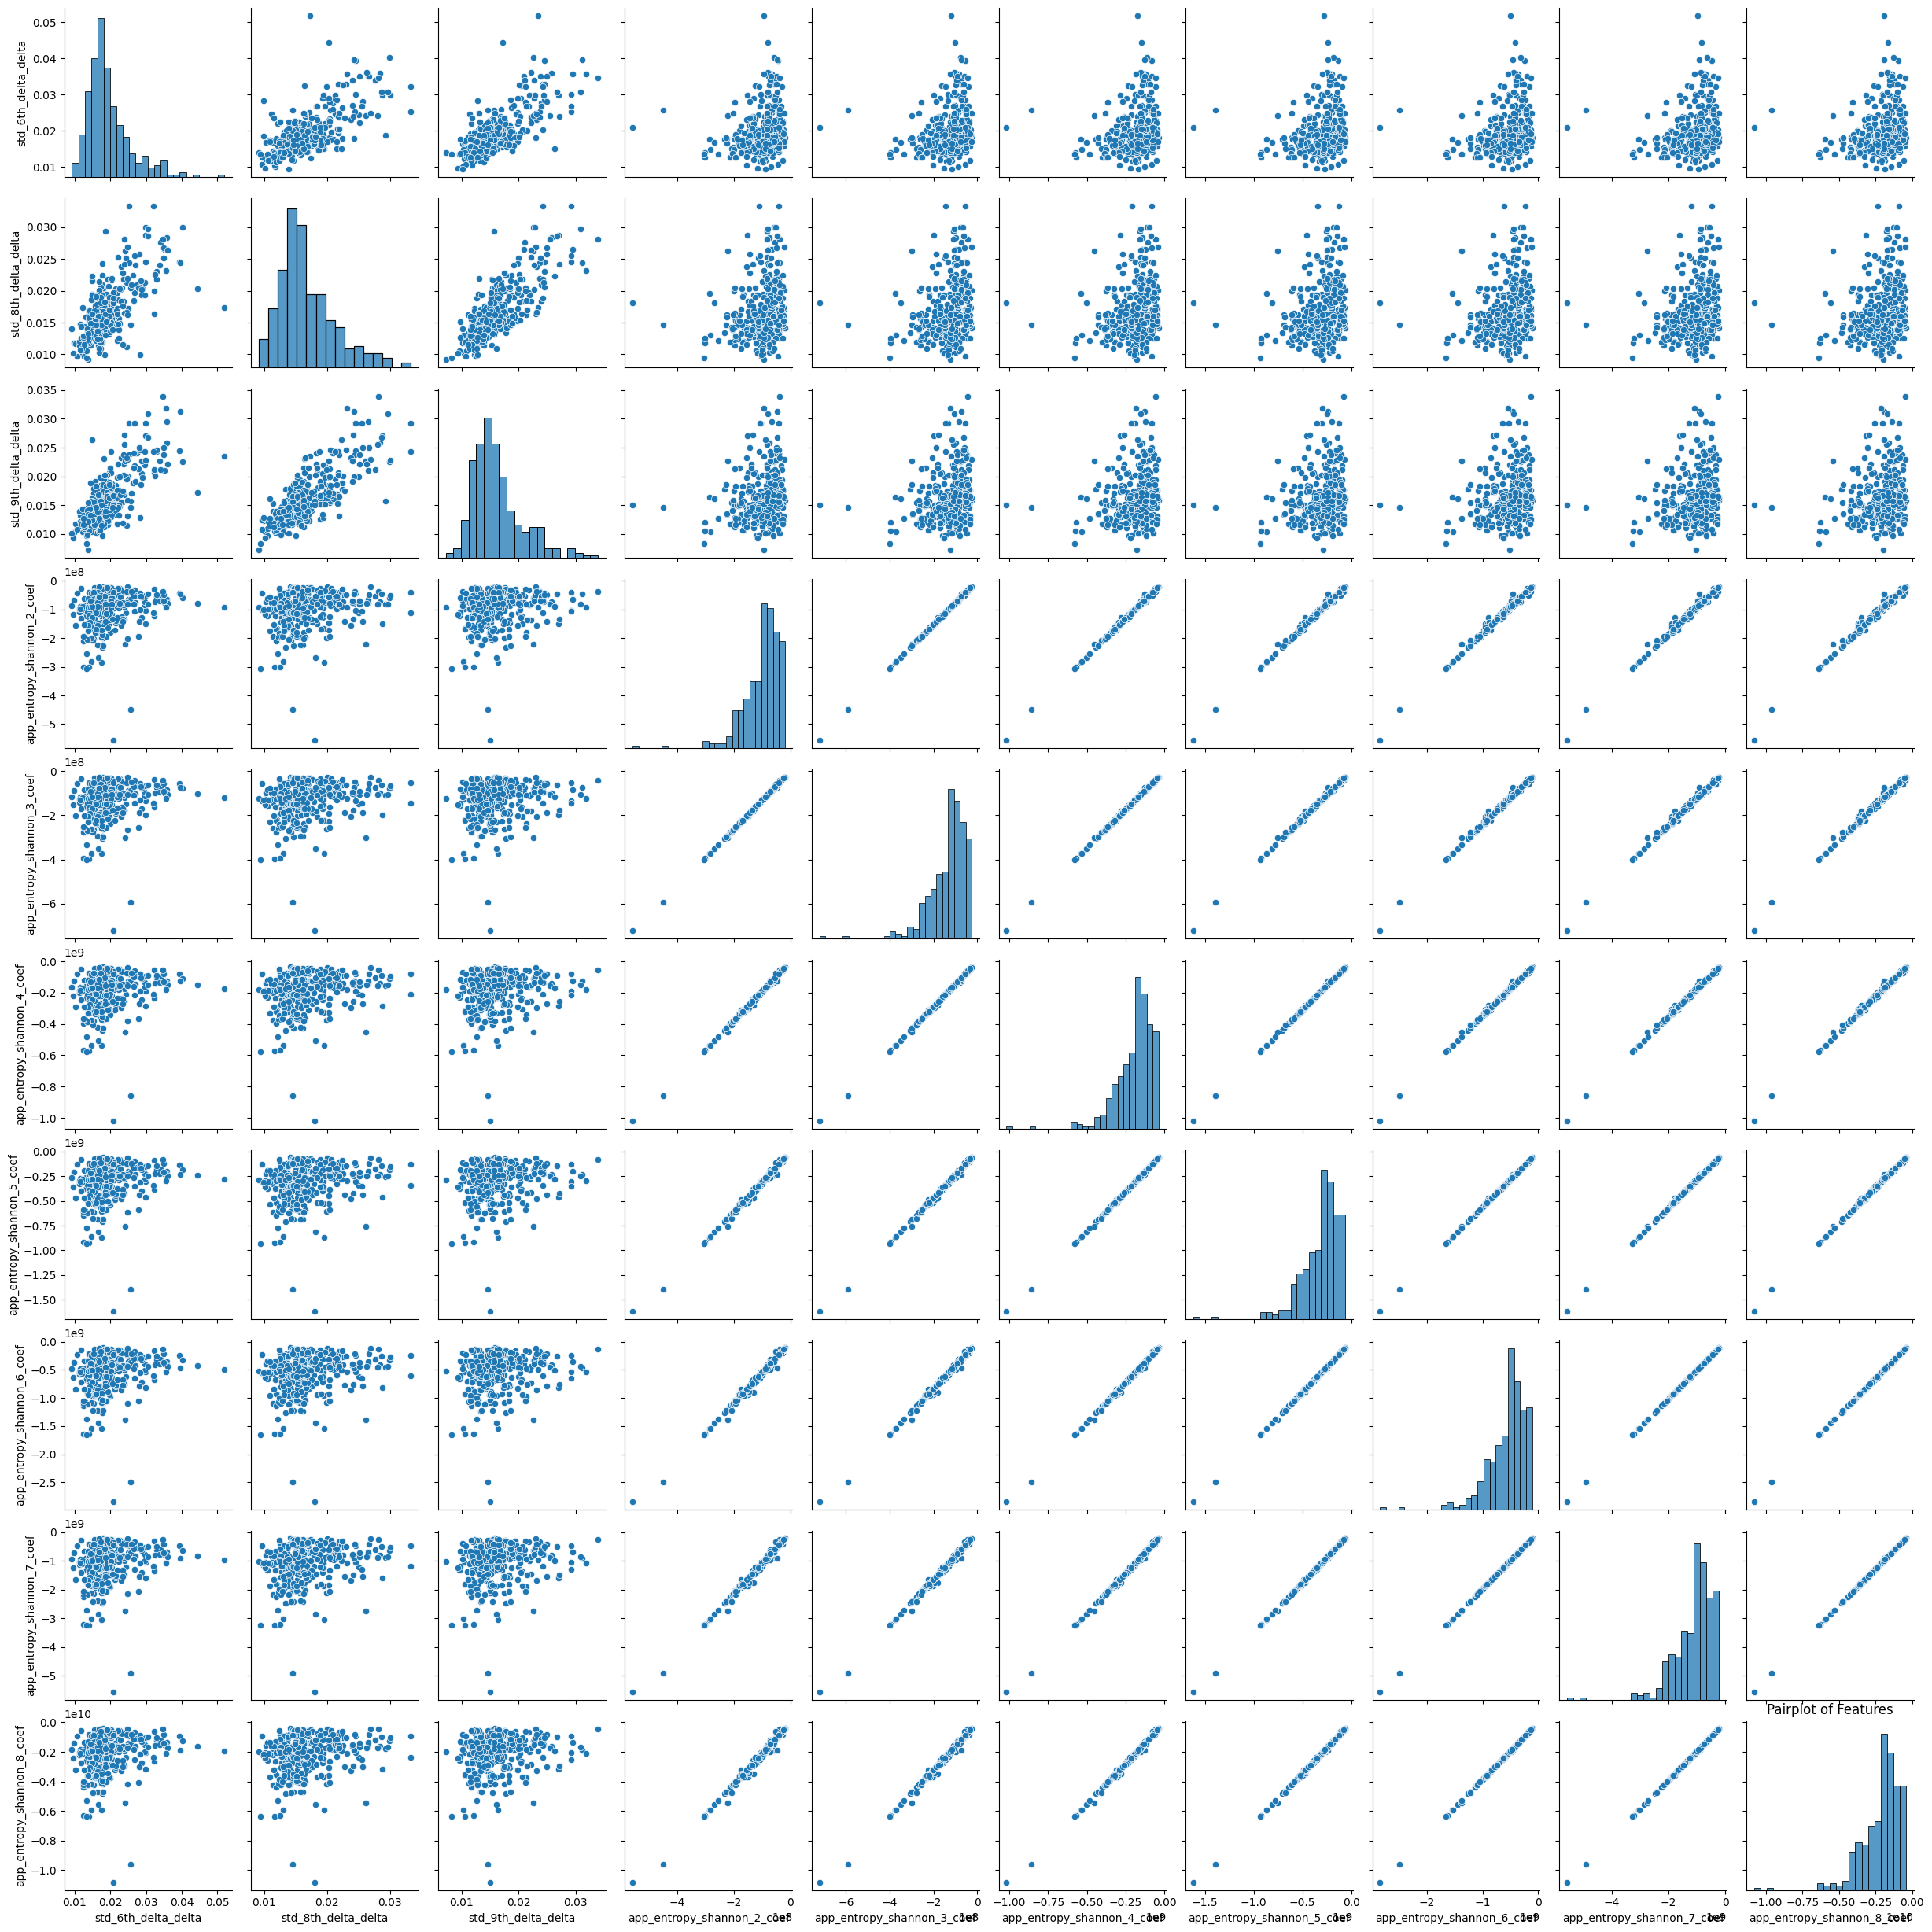

In [39]:
plt.figure(figsize=(20,20))
sns.pairplot(df.iloc[:, :10])
plt.title('Pairplot of Features')
plt.show()

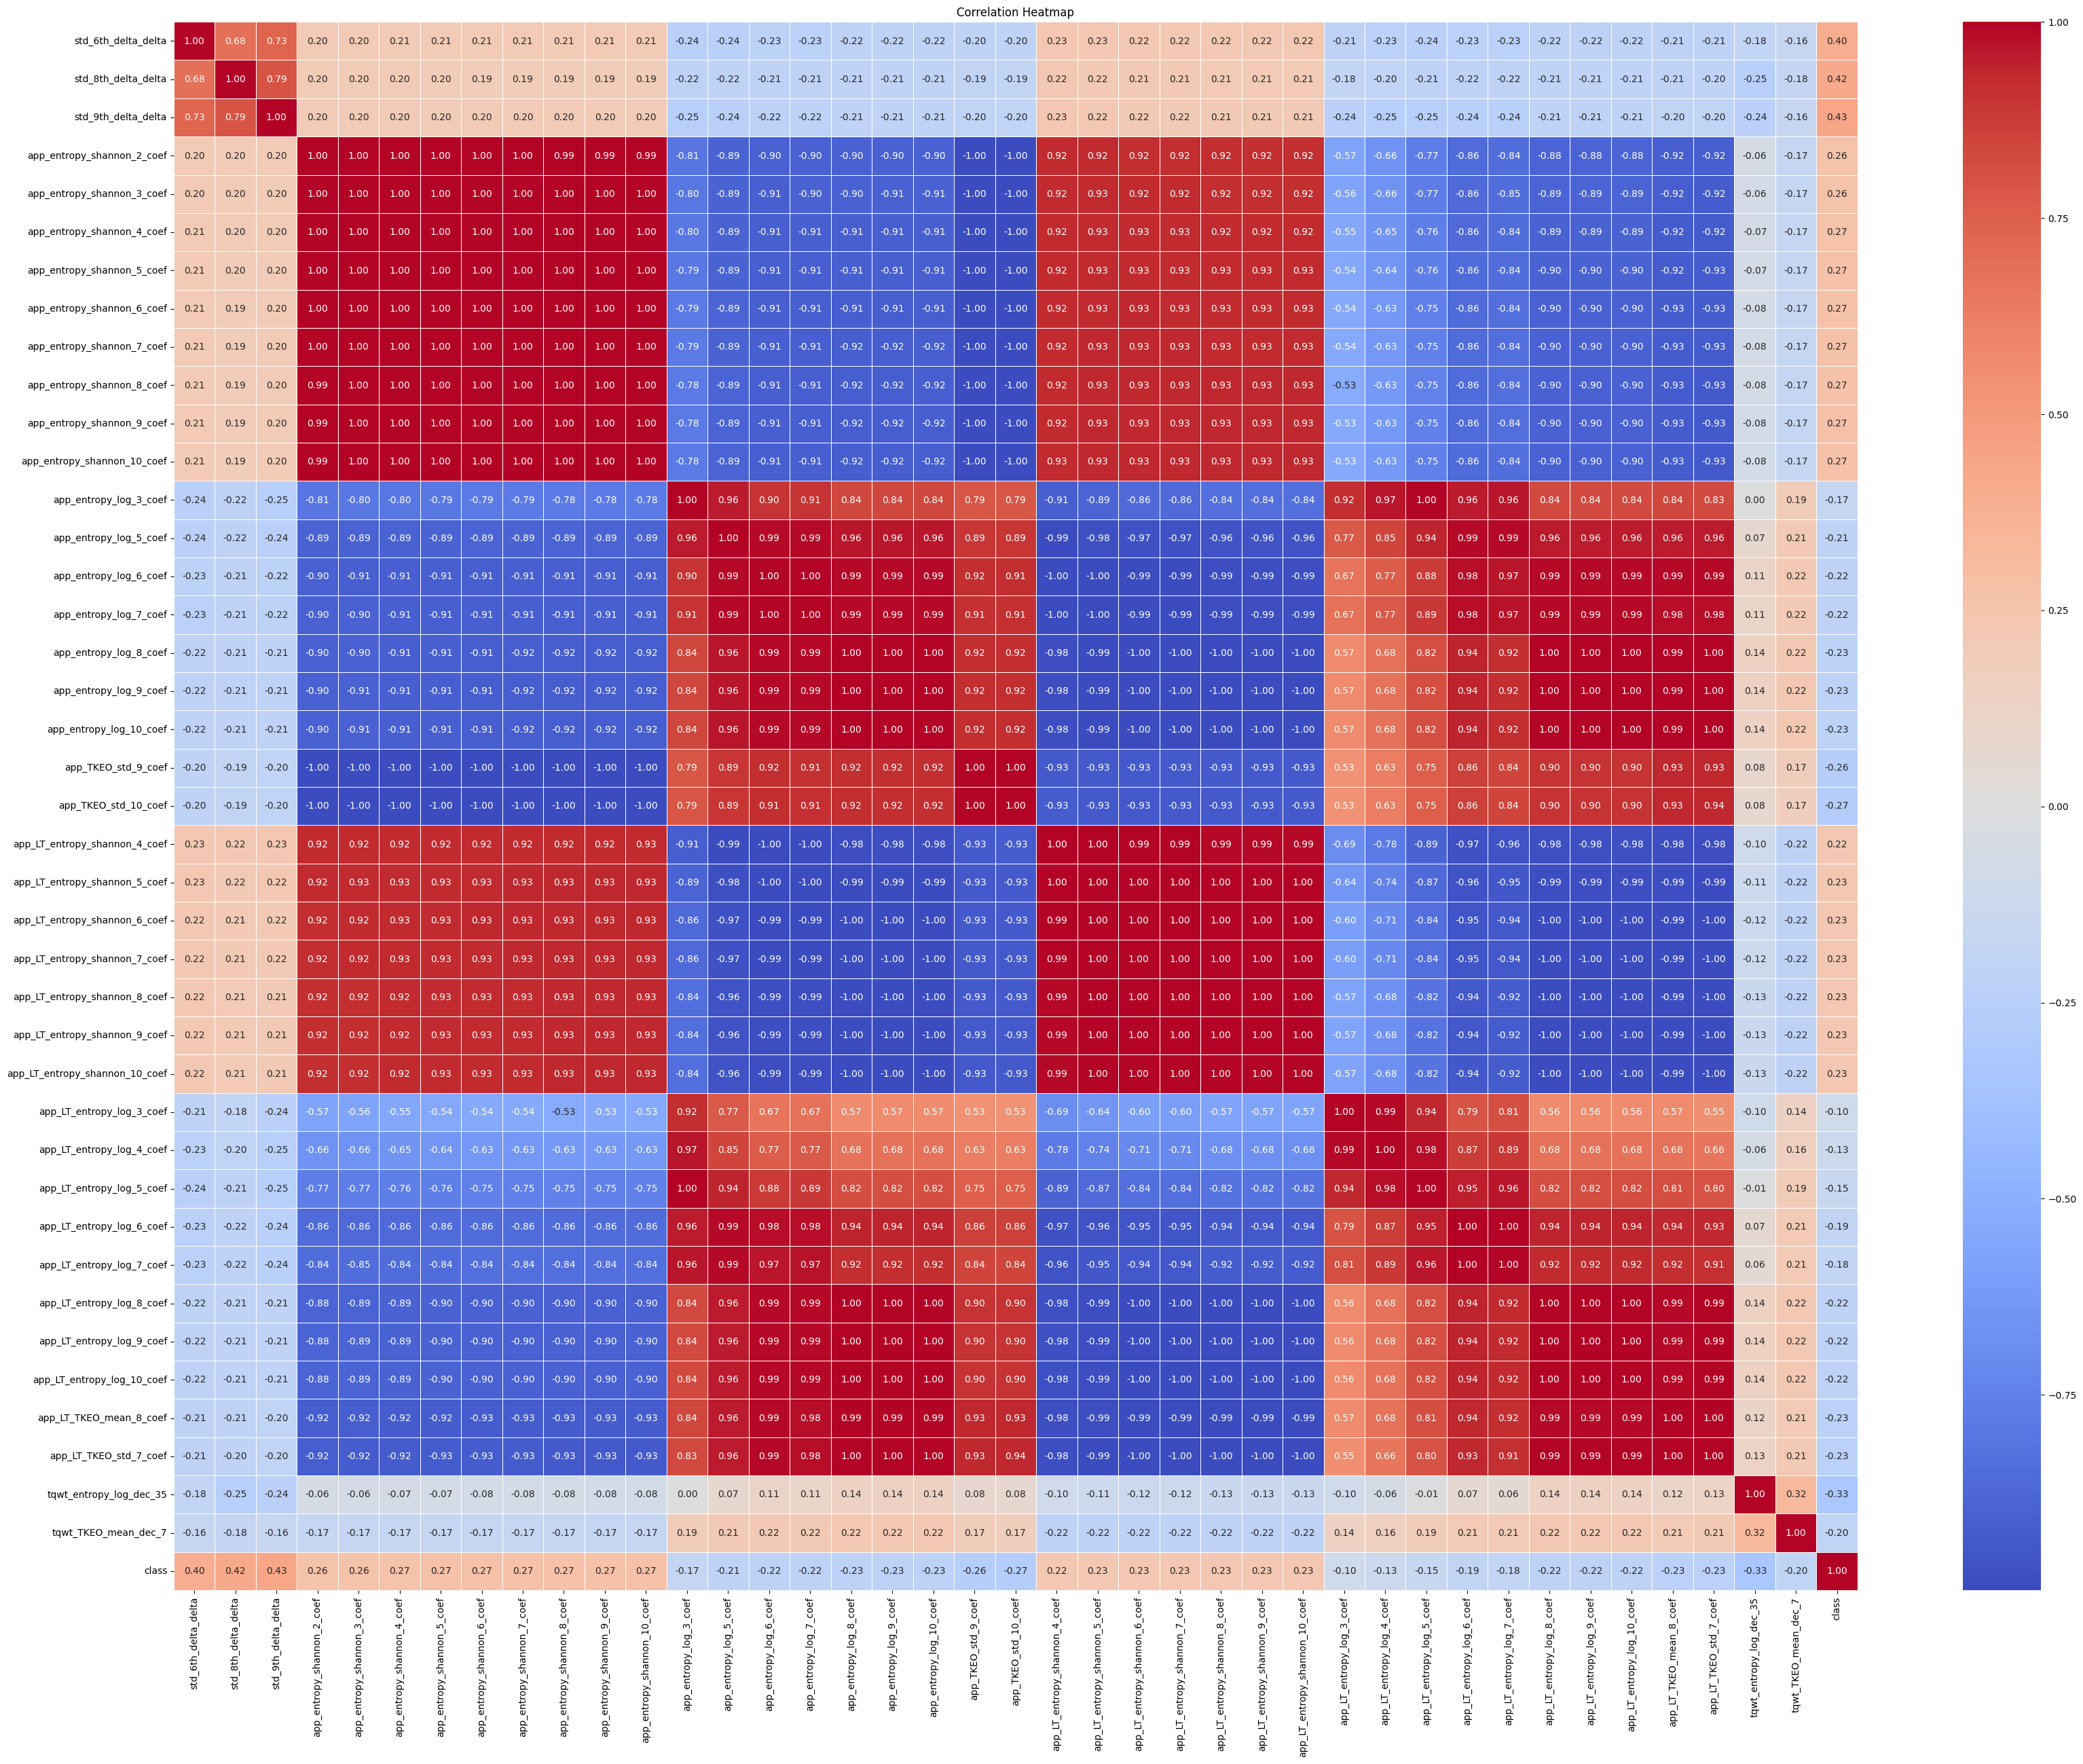

In [40]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(40,30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

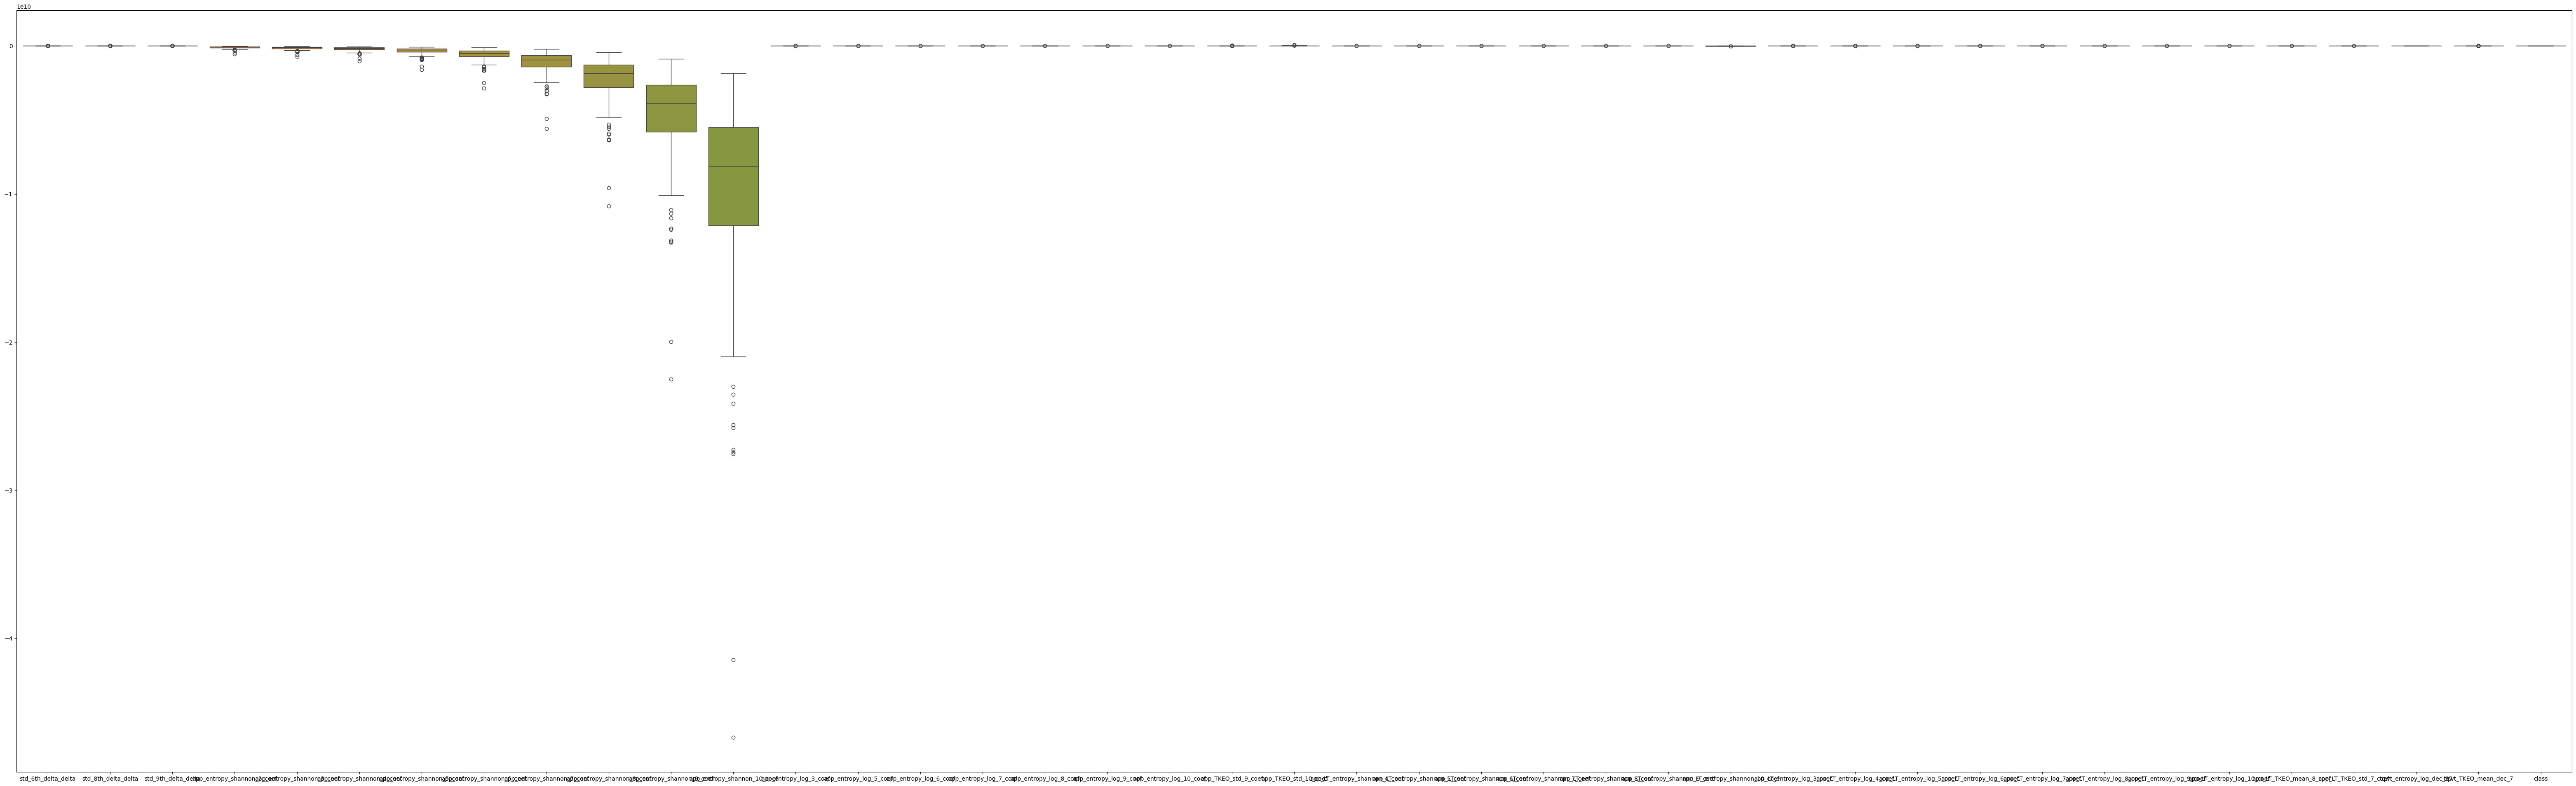

In [42]:
### Box Plot which is used for to check the outlier
plt.figure(figsize=(80, 24))
sns.boxplot(df)
plt.show()

In [44]:
def handle_outliers_iqr(df):
    # Iterate over each column in the DataFrame
    for column in df.columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        
        # Calculate IQR
        IQR = Q3 - Q1
        
        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Filter out the outliers
        df[column] = df[column].clip(lower_bound, upper_bound)
        
    return df

# Handle outliers in the dataset
df = handle_outliers_iqr(df)

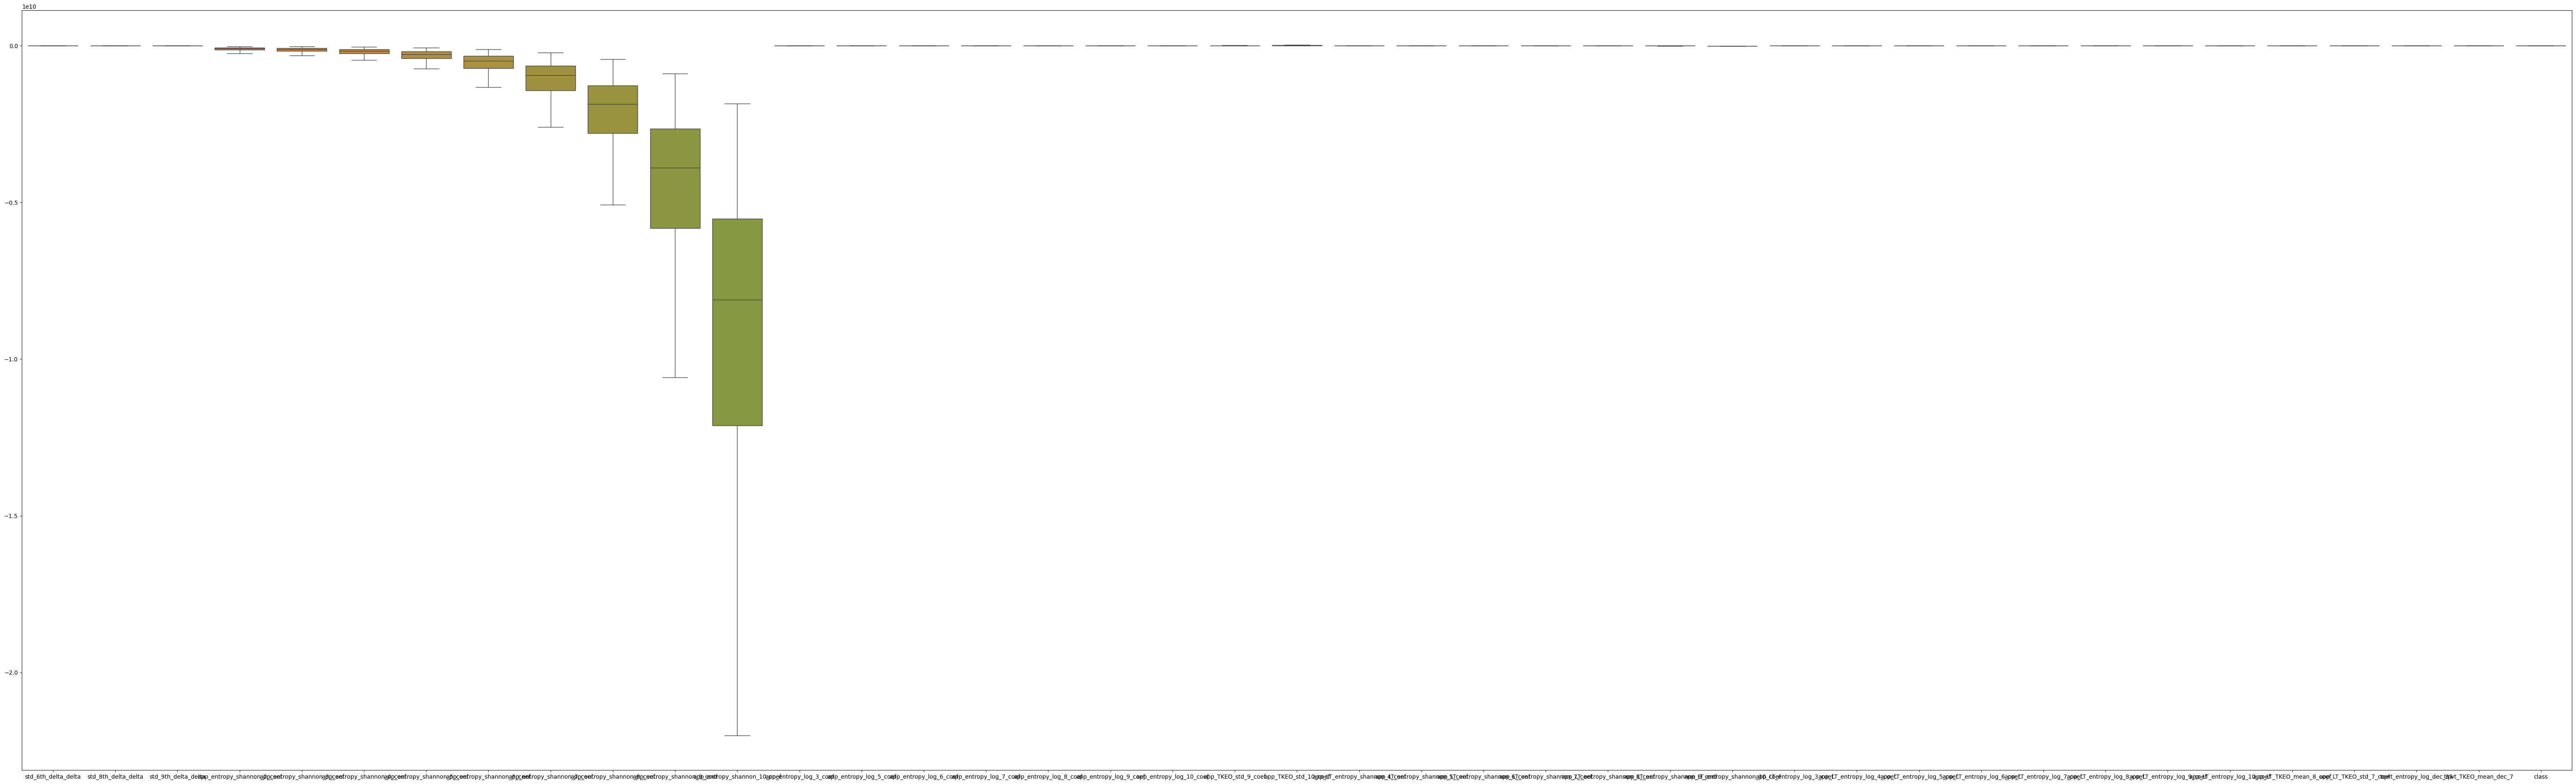

In [45]:
### Box Plot which is used for to check the After handelling outlier
plt.figure(figsize=(80, 24))
sns.boxplot(df)
plt.show()

In [46]:
## SPlitting the data into Training and Testing

x = df.drop('class', axis = 1)
y = df['class']

In [47]:
df['class'].value_counts().to_dict()

{1: 172, 0: 167}

In [48]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((237, 40), (102, 40), (237,), (102,))

In [49]:
x_test.head()

,std_6th_delta_delta,std_8th_delta_delta,std_9th_delta_delta,app_entropy_shannon_2_coef,app_entropy_shannon_3_coef,app_entropy_shannon_4_coef,app_entropy_shannon_5_coef,app_entropy_shannon_6_coef,app_entropy_shannon_7_coef,app_entropy_shannon_8_coef,...,app_LT_entropy_log_5_coef,app_LT_entropy_log_6_coef,app_LT_entropy_log_7_coef,app_LT_entropy_log_8_coef,app_LT_entropy_log_9_coef,app_LT_entropy_log_10_coef,app_LT_TKEO_mean_8_coef,app_LT_TKEO_std_7_coef,tqwt_entropy_log_dec_35,tqwt_TKEO_mean_dec_7
102,0.014769,0.013065,0.010371,-2.394561e+08,-3.136893e+08,-4.538304e+08,-7.360033e+08,-1.316432e+09,-2.592778e+09,-5.078673e+09,...,138.988553,129.925045,133.372542,135.434856,145.832056,156.229256,1110.778501,1423.052383,-2590.868696,0.000203
125,0.017052,0.015277,0.019802,-1.547398e+08,-2.030787e+08,-2.917909e+08,-4.701635e+08,-8.358791e+08,-1.645167e+09,-3.219169e+09,...,136.940500,128.175600,131.724600,133.887700,144.284900,154.682100,1003.441700,1286.717600,-2924.345700,0.000060
11,0.015107,0.013570,0.015915,-4.006492e+07,-5.292981e+07,-7.649386e+07,-1.239261e+08,-2.213424e+08,-4.372231e+08,-8.583105e+08,...,132.073500,124.038500,127.829600,130.234800,140.632000,151.029200,787.392000,1008.638700,-2999.458300,0.000011
248,0.014624,0.018637,0.015745,-4.326859e+07,-5.737918e+07,-8.335712e+07,-1.356832e+08,-2.432029e+08,-4.809256e+08,-9.457816e+08,...,132.422300,124.347700,128.124900,130.517600,140.914800,151.312000,798.750400,1023.848900,-3064.440300,0.000007
238,0.017179,0.013831,0.013323,-4.620874e+07,-6.120844e+07,-8.876725e+07,-1.442338e+08,-2.582607e+08,-5.107735e+08,-1.003813e+09,...,132.656500,124.544200,128.310800,130.690500,141.087700,151.484900,809.935800,1038.158300,-3067.204200,0.000003


In [50]:
y_test.head()

102    0
125    1
11     0
248    0
238    1
Name: class, dtype: int64

In [51]:
values = df.loc[[102]]
values

,std_6th_delta_delta,std_8th_delta_delta,std_9th_delta_delta,app_entropy_shannon_2_coef,app_entropy_shannon_3_coef,app_entropy_shannon_4_coef,app_entropy_shannon_5_coef,app_entropy_shannon_6_coef,app_entropy_shannon_7_coef,app_entropy_shannon_8_coef,...,app_LT_entropy_log_6_coef,app_LT_entropy_log_7_coef,app_LT_entropy_log_8_coef,app_LT_entropy_log_9_coef,app_LT_entropy_log_10_coef,app_LT_TKEO_mean_8_coef,app_LT_TKEO_std_7_coef,tqwt_entropy_log_dec_35,tqwt_TKEO_mean_dec_7,class
102,0.014769,0.013065,0.010371,-2.394561e+08,-3.136893e+08,-4.538304e+08,-7.360033e+08,-1.316432e+09,-2.592778e+09,-5.078673e+09,...,129.925045,133.372542,135.434856,145.832056,156.229256,1110.778501,1423.052383,-2590.868696,0.000203,0


# **Model Training**

**Random Forest**

In [53]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

y_pred = rf.predict(x_train)
acc_rf = accuracy_score(y_train, y_pred)
ps_rf = precision_score(y_train, y_pred)
rs_rf = recall_score(y_train, y_pred)
f1_rf = f1_score(y_train, y_pred)

print(f'accuracy = {acc_rf}')
print(f'Precision Score = {ps_rf}')
print(f'Recall Score = {rs_rf}')
print(f'F1 Score = {f1_rf}')

accuracy = 1.0
Precision Score = 1.0
Recall Score = 1.0
F1 Score = 1.0


Here is the confusion matrix of the model 
 
 [[111   0]
 [  0 126]]


<Axes: >

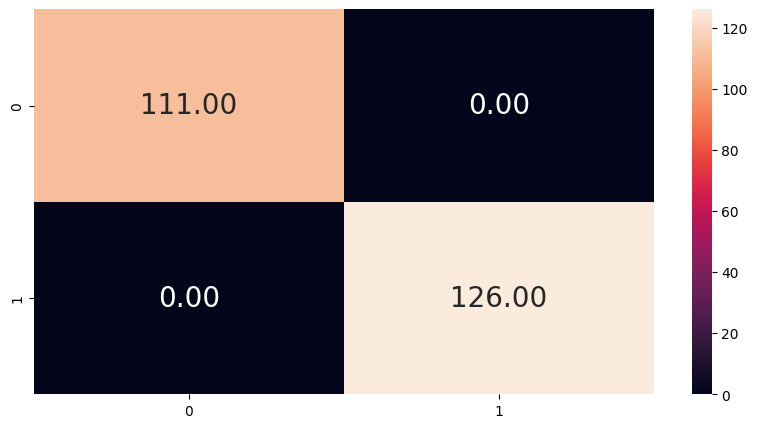

In [57]:
# confusion matrix of the model
print(f'Here is the confusion matrix of the model \n \n {confusion_matrix(y_train,y_pred)}')

# plot the confusion matrix for the model 
plt.figure(figsize=(10,5))

sns.heatmap(confusion_matrix(y_train,y_pred),annot=True,fmt='0.2f',annot_kws={'size':20})

Here is the auc score of the model 1.0


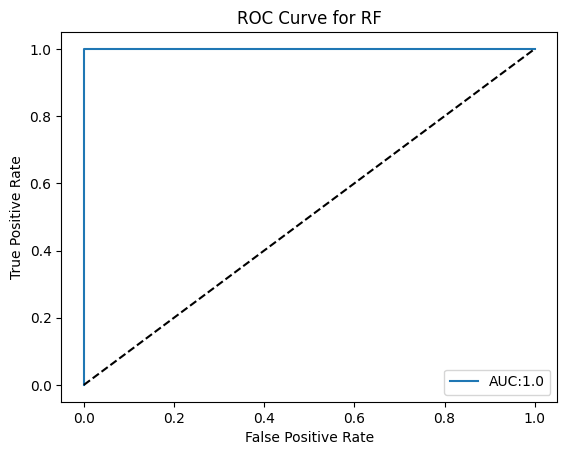

In [58]:
# print the auc score of the model
print(f'Here is the auc score of the model {roc_auc_score(y_train,y_pred)}')

# plot the roc curve for the model with roc score adn the model name inside the plot
fpr,tpr,thresholds = roc_curve(y_train,y_pred)
plt.plot(fpr,tpr,label=f'AUC:{roc_auc_score(y_train,y_pred)}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for RF')
plt.legend(loc='lower right')
plt.show()

In [59]:
y_pred = rf.predict(x_test)
acc_rf = accuracy_score(y_test, y_pred)
ps_rf = precision_score(y_test, y_pred)
rs_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

print(f'accuracy = {acc_rf}')
print(f'Precision Score = {ps_rf}')
print(f'Recall Score = {rs_rf}')
print(f'F1 Score = {f1_rf}')

accuracy = 0.8235294117647058
Precision Score = 0.75
Recall Score = 0.9130434782608695
F1 Score = 0.8235294117647058


Here is the confusion matrix of the model 
 
 [[42 14]
 [ 4 42]]


<Axes: >

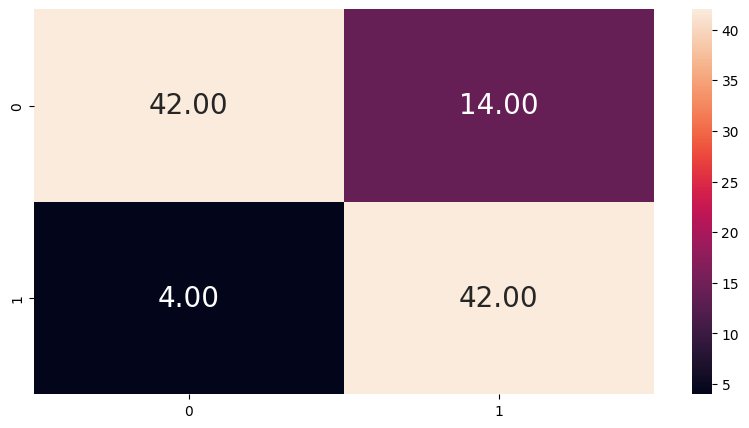

In [60]:
# confusion matrix of the model
print(f'Here is the confusion matrix of the model \n \n {confusion_matrix(y_test,y_pred)}')

# plot the confusion matrix for the model 
plt.figure(figsize=(10,5))

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='0.2f',annot_kws={'size':20})

Here is the auc score of the model 0.8315217391304348


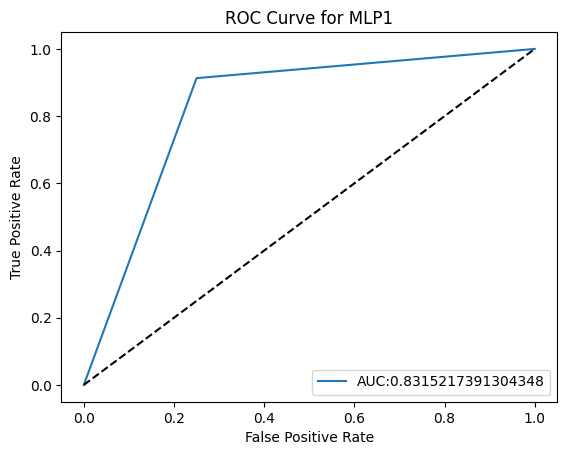

In [61]:
# print the auc score of the model
print(f'Here is the auc score of the model {roc_auc_score(y_test,y_pred)}')

# plot the roc curve for the model with roc score adn the model name inside the plot
fpr,tpr,thresholds = roc_curve(y_test,y_pred)
plt.plot(fpr,tpr,label=f'AUC:{roc_auc_score(y_test,y_pred)}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for MLP1')
plt.legend(loc='lower right')
plt.show()

**Hyper Parameter Tunning for Random Forest**

In [62]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [10, 50, 100, 200],        # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],           # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],           # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],             # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False]                 # Whether bootstrap samples are used when building trees
}

# Initialize GridSearchCV
grid_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_

print("Best Parameters:", best_params)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'bootstrap': True}


In [63]:
from sklearn.ensemble import RandomForestClassifier
rf_hyp = RandomForestClassifier( n_estimators = 200, min_samples_split = 5, min_samples_leaf = 2, max_depth = 10, bootstrap = True)
rf_hyp.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

y_pred = rf_hyp.predict(x_train)
acc_rf_hyp = accuracy_score(y_train, y_pred)
ps_rf_hyp = precision_score(y_train, y_pred)
rs_rf_hyp = recall_score(y_train, y_pred)
f1_rf_hyp = f1_score(y_train, y_pred)

print(f'accuracy = {acc_rf_hyp}')
print(f'Precision Score = {ps_rf_hyp}')
print(f'Recall Score = {rs_rf_hyp}')
print(f'F1 Score = {f1_rf_hyp}')

accuracy = 0.9873417721518988
Precision Score = 0.992
Recall Score = 0.9841269841269841
F1 Score = 0.9880478087649402


Here is the confusion matrix of the model 
 
 [[110   1]
 [  2 124]]


<Axes: >

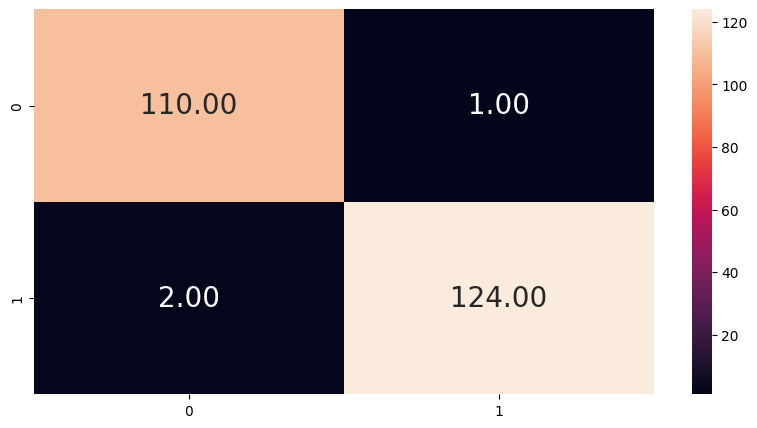

In [65]:
# confusion matrix of the model
print(f'Here is the confusion matrix of the model \n \n {confusion_matrix(y_train,y_pred)}')

# plot the confusion matrix for the model 
plt.figure(figsize=(10,5))

sns.heatmap(confusion_matrix(y_train,y_pred),annot=True,fmt='0.2f',annot_kws={'size':20})

Here is the auc score of the model 0.9875589875589875


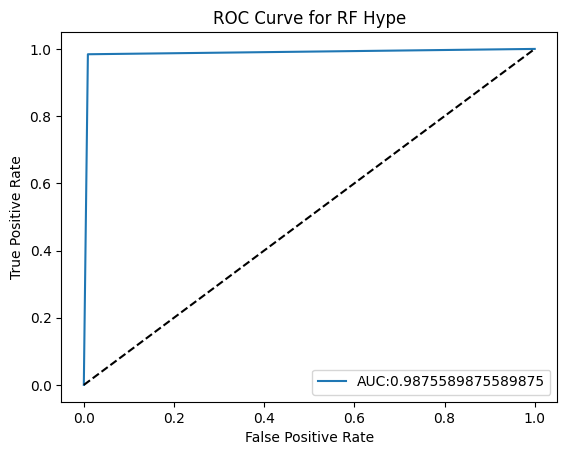

In [66]:
# print the auc score of the model
print(f'Here is the auc score of the model {roc_auc_score(y_train,y_pred)}')

# plot the roc curve for the model with roc score adn the model name inside the plot
fpr,tpr,thresholds = roc_curve(y_train,y_pred)
plt.plot(fpr,tpr,label=f'AUC:{roc_auc_score(y_train,y_pred)}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for RF Hype')
plt.legend(loc='lower right')
plt.show()

In [67]:
y_pred = rf_hyp.predict(x_test)
acc_rf_hyp = accuracy_score(y_test, y_pred)
ps_rf_hyp = precision_score(y_test, y_pred)
rs_rf_hyp = recall_score(y_test, y_pred)
f1_rf_hyp = f1_score(y_test, y_pred)

print(f'accuracy = {acc_rf_hyp}')
print(f'Precision Score = {ps_rf_hyp}')
print(f'Recall Score = {rs_rf_hyp}')
print(f'F1 Score = {f1_rf_hyp}')

accuracy = 0.8137254901960784
Precision Score = 0.7454545454545455
Recall Score = 0.8913043478260869
F1 Score = 0.8118811881188119


Here is the confusion matrix of the model 
 
 [[42 14]
 [ 5 41]]


<Axes: >

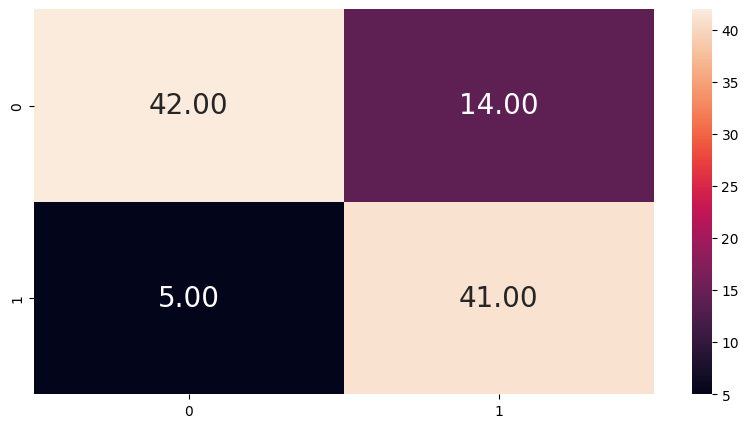

In [68]:
# confusion matrix of the model
print(f'Here is the confusion matrix of the model \n \n {confusion_matrix(y_test,y_pred)}')

# plot the confusion matrix for the model 
plt.figure(figsize=(10,5))

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='0.2f',annot_kws={'size':20})

Here is the auc score of the model 0.8206521739130435


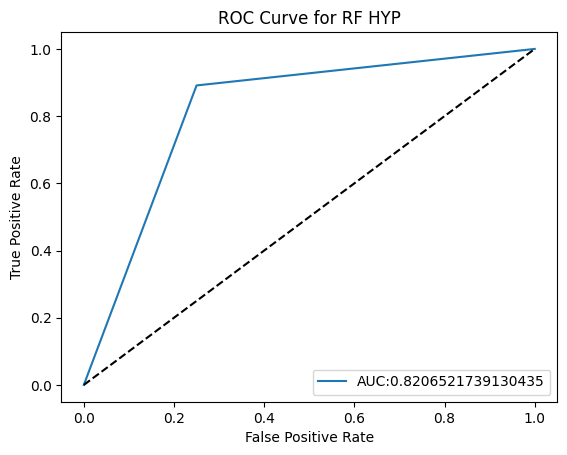

In [69]:
# print the auc score of the model
print(f'Here is the auc score of the model {roc_auc_score(y_test,y_pred)}')

# plot the roc curve for the model with roc score adn the model name inside the plot
fpr,tpr,thresholds = roc_curve(y_test,y_pred)
plt.plot(fpr,tpr,label=f'AUC:{roc_auc_score(y_test,y_pred)}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for RF HYP')
plt.legend(loc='lower right')
plt.show()

**SVM**

In [70]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [71]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

y_pred = svm.predict(x_train)
acc_svm = accuracy_score(y_train, y_pred)
ps_svm = precision_score(y_train, y_pred)
rs_svm = recall_score(y_train, y_pred)
f1_svm = f1_score(y_train, y_pred)

print(f'accuracy = {acc_svm}')
print(f'Precision Score = {ps_svm}')
print(f'Recall Score = {rs_svm}')
print(f'F1 Score = {f1_svm}')

accuracy = 0.6075949367088608
Precision Score = 0.5854922279792746
Recall Score = 0.8968253968253969
F1 Score = 0.7084639498432602


Here is the confusion matrix of the model 
 
 [[ 31  80]
 [ 13 113]]


<Axes: >

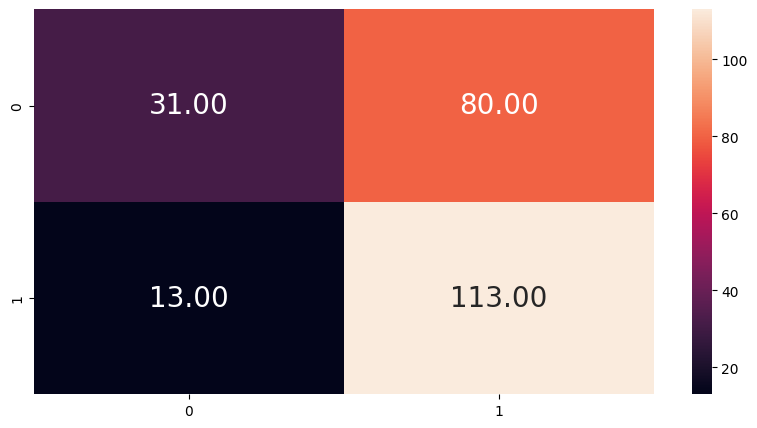

In [72]:
# confusion matrix of the model
print(f'Here is the confusion matrix of the model \n \n {confusion_matrix(y_train,y_pred)}')

# plot the confusion matrix for the model 
plt.figure(figsize=(10,5))

sns.heatmap(confusion_matrix(y_train,y_pred),annot=True,fmt='0.2f',annot_kws={'size':20})

Here is the auc score of the model 0.5880523380523381


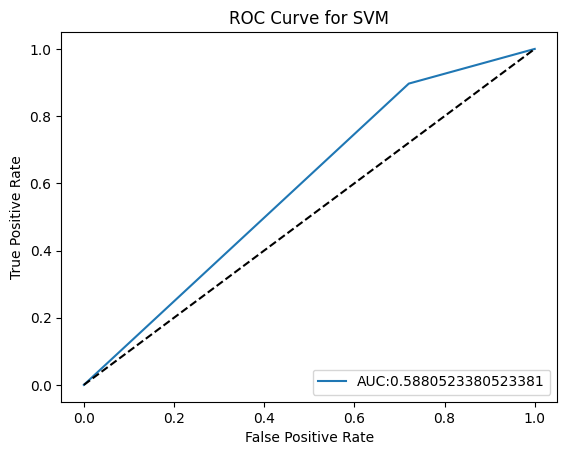

In [73]:
# print the auc score of the model
print(f'Here is the auc score of the model {roc_auc_score(y_train,y_pred)}')

# plot the roc curve for the model with roc score adn the model name inside the plot
fpr,tpr,thresholds = roc_curve(y_train,y_pred)
plt.plot(fpr,tpr,label=f'AUC:{roc_auc_score(y_train,y_pred)}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM')
plt.legend(loc='lower right')
plt.show()

In [74]:
y_pred = svm.predict(x_test)
acc_svm = accuracy_score(y_test, y_pred)
ps_svm = precision_score(y_test, y_pred)
rs_svm = recall_score(y_test, y_pred)
f1_svm = f1_score(y_test, y_pred)

print(f'accuracy = {acc_svm}')
print(f'Precision Score = {ps_svm}')
print(f'Recall Score = {rs_svm}')
print(f'F1 Score = {f1_svm}')

accuracy = 0.5784313725490197
Precision Score = 0.52
Recall Score = 0.8478260869565217
F1 Score = 0.6446280991735537


Here is the confusion matrix of the model 
 
 [[20 36]
 [ 7 39]]


<Axes: >

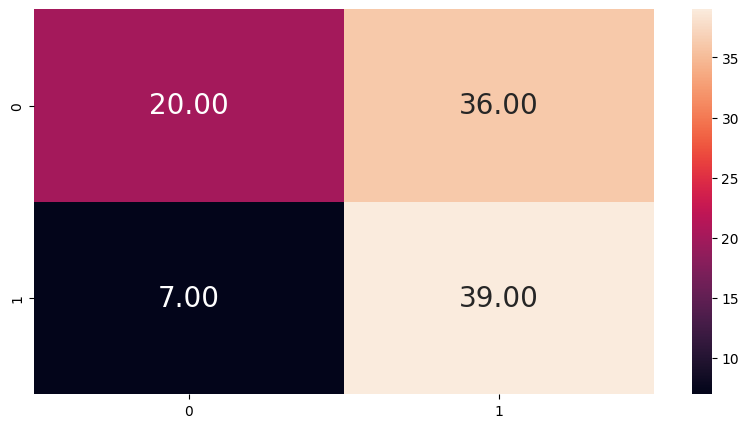

In [75]:
# confusion matrix of the model
print(f'Here is the confusion matrix of the model \n \n {confusion_matrix(y_test,y_pred)}')

# plot the confusion matrix for the model 
plt.figure(figsize=(10,5))

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='0.2f',annot_kws={'size':20})

Here is the auc score of the model 0.6024844720496894


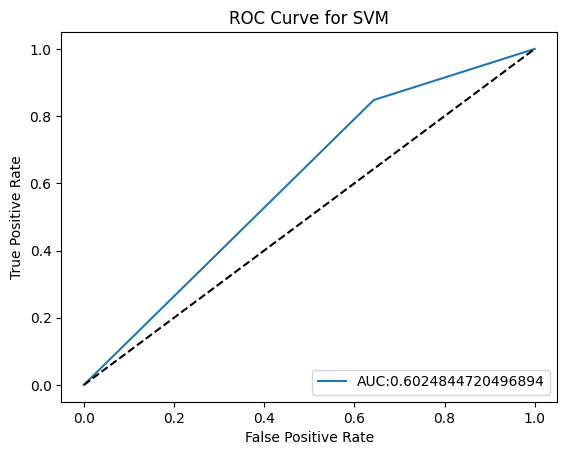

In [76]:
# print the auc score of the model
print(f'Here is the auc score of the model {roc_auc_score(y_test,y_pred)}')

# plot the roc curve for the model with roc score adn the model name inside the plot
fpr,tpr,thresholds = roc_curve(y_test,y_pred)
plt.plot(fpr,tpr,label=f'AUC:{roc_auc_score(y_test,y_pred)}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM')
plt.legend(loc='lower right')
plt.show()

**Hyperparamter tunning for SVM**

In [77]:
# from sklearn.svm import SVC
# from sklearn.model_selection import RandomizedSearchCV

# svm =SVC()
# # Define the parameter grid
# param_grid = {
#     'C': [0.1, 1, 10, 100],                # Regularization parameter
#     'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Kernel type
# #     'degree': [2, 3, 4],                   # Degree of the polynomial kernel function (ignored if kernel != 'poly')
# #     'gamma': ['scale', 'auto', 0.1, 1, 10] # Kernel coefficient (ignored if kernel='linear')
# }

# # Initialize RandomizedSearchCV
# grid_search = RandomizedSearchCV(estimator=svm, param_distributions=param_grid, cv=5, n_jobs=-1, verbose=2)

# # Fit RandomizedSearchCV
# grid_search.fit(x_train[:200], y_train[:200])

# # Get the best parameters and best score
# best_params = grid_search.best_params_

# print("Best Parameters:", best_params)

**CNN**

In [84]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Assuming you have X_train, X_test, y_train, y_test from your dataset

# Encode categorical labels into numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Standardize the data (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

# Reshape data to fit the format required by CNN (add a channel dimension)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Define the CNN model
cnn = Sequential([
    Conv1D(32, 1, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(2),
    Conv1D(64, 1, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')  # Softmax for multiclass classification
])

# Compile the model for multiclass classification
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Sparse categorical cross-entropy for multiclass classification
              metrics=['accuracy'])  # Accuracy as a metric

# Train the model
cnn.fit(X_train, y_train_encoded, epochs=10, batch_size=128, validation_data=(X_test, y_test_encoded))

Epoch 1/10


/opt/anaconda3/envs/pythonfs/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4515 - loss: 0.7303 - val_accuracy: 0.6176 - val_loss: 0.6469
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6371 - loss: 0.6616 - val_accuracy: 0.6667 - val_loss: 0.6352
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6203 - loss: 0.6559 - val_accuracy: 0.6765 - val_loss: 0.6228
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6456 - loss: 0.6192 - val_accuracy: 0.6961 - val_loss: 0.6072
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6624 - loss: 0.6172 - val_accuracy: 0.7059 - val_loss: 0.5915
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6456 - loss: 0.5948 - val_accuracy: 0.6961 - val_loss: 0.5803
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7004 - loss: 0.5816 - val_accuracy: 0.7059 - val_loss: 0.5708
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6540 - loss: 0.5698 - val_accuracy: 0.6961 - val_loss: 0.5618
Epoch 9/10

In [86]:
# Evaluate the model on test data
loss, accuracy = cnn.evaluate(X_train, y_train_encoded)
print(f'Accuracy: {accuracy * 100:.2f}%')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6793 - loss: 0.5328 
Accuracy: 67.93%


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


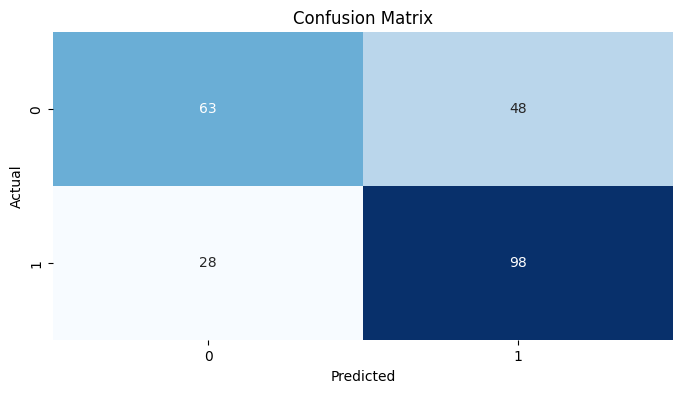

In [87]:
from sklearn.metrics import confusion_matrix
# Make predictions on the training data
y_pred = cnn.predict(X_train)

# If y_train_encoded is already in label format, no need to use np.argmax on it
if len(y_train_encoded.shape) > 1:
    y_true = np.argmax(y_train_encoded, axis=1)
else:
    y_true = y_train_encoded

# Convert the predictions from probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [90]:
# Evaluate the model on test data
loss, accuracy = cnn.evaluate(X_test, y_test_encoded)
print(f'Accuracy: {accuracy * 100:.2f}%')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7157 - loss: 0.5517 
Accuracy: 71.57%


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


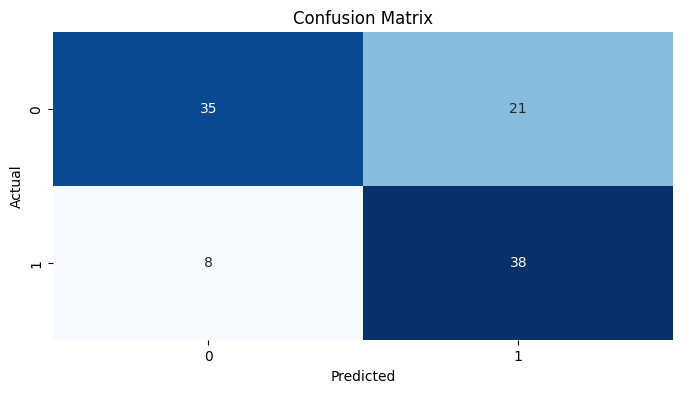

In [91]:
from sklearn.metrics import confusion_matrix
# Make predictions on the training data
y_pred = cnn.predict(X_test)

# If y_train_encoded is already in label format, no need to use np.argmax on it
if len(y_test_encoded.shape) > 1:
    y_true = np.argmax(y_test_encoded, axis=1)
else:
    y_true = y_test_encoded

# Convert the predictions from probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()